# Mutual Fund Analytics Capstone Project

## Exploratory Data Analysis (EDA)

**Intern:** Chirag Nagra

**Company:** Bluestock Fintech MJ28

**Project:** Mutual Fund Analytics

**Date:** 04 June 2026

In [479]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [480]:
from pathlib import Path

DATA = Path("../data/processed")

funds = pd.read_csv(DATA / "fund_master_clean.csv")
nav = pd.read_csv(DATA / "nav_history_clean.csv")
perf = pd.read_csv(DATA / "scheme_performance_clean.csv")
tx = pd.read_csv(DATA / "investor_transactions_clean.csv")

In [481]:
print("Funds Shape:", funds.shape)
print("NAV Shape:", nav.shape)
print("Performance Shape:", perf.shape)
print("Transactions Shape:", tx.shape)

Funds Shape: (40, 15)
NAV Shape: (46000, 3)
Performance Shape: (40, 19)
Transactions Shape: (32778, 13)


In [482]:
funds["category"].value_counts()

category
Equity    34
Debt       6
Name: count, dtype: int64

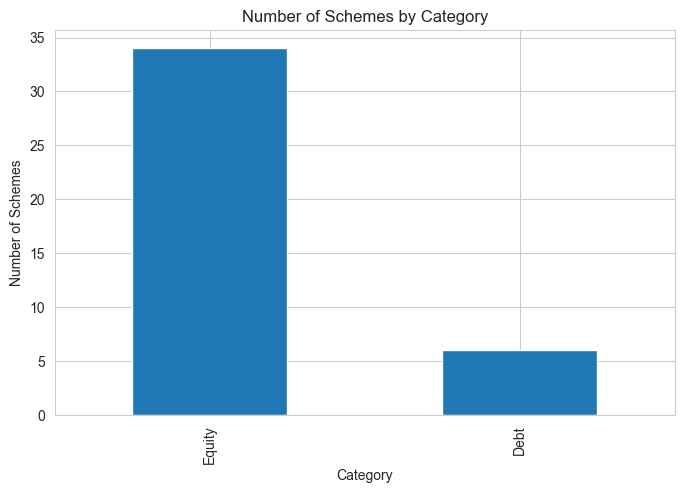

In [483]:
plt.figure(figsize=(8,5))

funds["category"].value_counts().plot(
    kind="bar"
)

plt.title("Number of Schemes by Category")
plt.xlabel("Category")
plt.ylabel("Number of Schemes")

plt.show()

### Insight 1

Equity funds dominate the mutual fund universe with 34 schemes out of 40 total schemes (85%), while Debt funds account for only 6 schemes (15%). This indicates a strong focus on equity-oriented investment products.

In [484]:
funds["fund_house"].value_counts()

fund_house
SBI Mutual Fund             5
HDFC Mutual Fund            5
ICICI Prudential MF         5
Nippon India MF             5
Kotak Mahindra MF           4
Axis Mutual Fund            4
Aditya Birla Sun Life MF    3
UTI Mutual Fund             3
Mirae Asset MF              3
DSP Mutual Fund             3
Name: count, dtype: int64

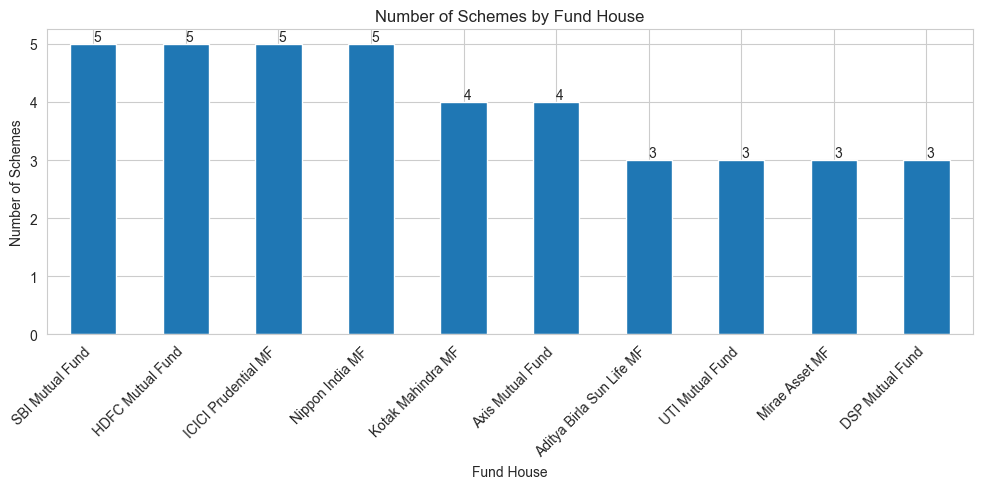

In [485]:
plt.figure(figsize=(10,5))

ax = funds["fund_house"].value_counts().plot(
    kind="bar"
)

plt.title("Number of Schemes by Fund House")
plt.xlabel("Fund House")
plt.ylabel("Number of Schemes")

plt.xticks(rotation=45, ha="right")

for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + 0.25, p.get_height() + 0.05)
    )

plt.tight_layout()
plt.show()

### Insight 2

SBI Mutual Fund, HDFC Mutual Fund, ICICI Prudential MF, and Nippon India MF have the highest number of schemes in the dataset, indicating strong product diversification among leading asset management companies.

In [486]:
nav["date"] = pd.to_datetime(nav["date"])

nav.dtypes

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object

In [487]:
daily_nav = (
    nav.groupby("date")["nav"]
       .mean()
       .reset_index()
)

daily_nav.head()

,date,nav
0,2022-01-03,207.213793
1,2022-01-04,206.890585
2,2022-01-05,207.226548
3,2022-01-06,207.190405
4,2022-01-07,207.081100


In [488]:
fig = px.line(
    daily_nav,
    x="date",
    y="nav",
    title="Average Daily NAV Trend (2022-2026)"
)

fig.show()

### Insight 3

The average NAV across all mutual fund schemes shows a generally upward trend over the analysis period, indicating long-term value appreciation and overall growth in the mutual fund market.

In [489]:
tx["age_group"].value_counts()

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

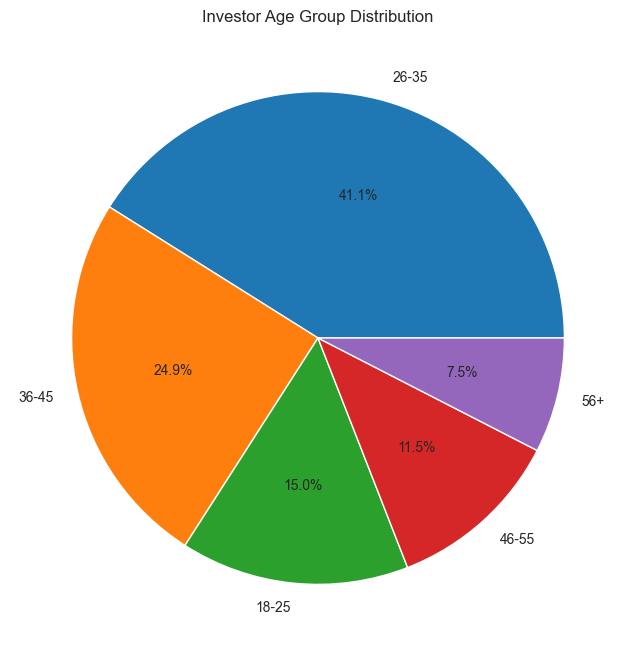

In [490]:
plt.figure(figsize=(8,8))

tx["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Investor Age Group Distribution")

plt.show()

### Insight 4

The 26–35 age group represents the largest investor segment with 13,463 investors, accounting for a significant share of total participation. This indicates strong mutual fund adoption among young working professionals.

In [491]:
tx["gender"].value_counts()

gender
Male      21809
Female    10969
Name: count, dtype: int64

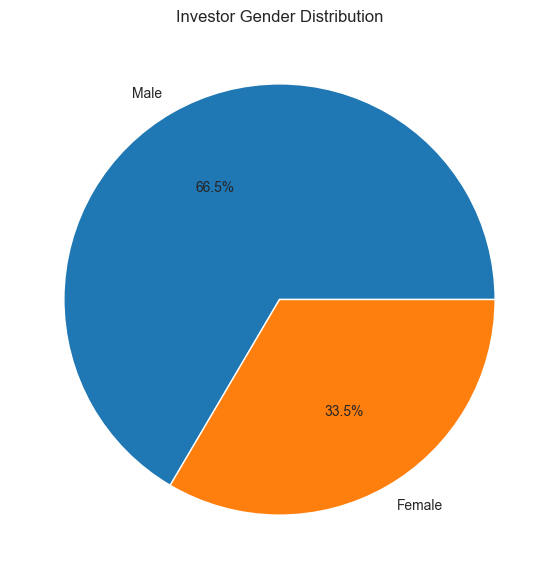

In [492]:
plt.figure(figsize=(7,7))

tx["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Investor Gender Distribution")

plt.show()

### Insight 5

Male investors account for approximately two-thirds of all transactions, while female investors represent nearly one-third. This suggests that mutual fund participation remains male-dominated, though female participation is significant and growing.

In [493]:
tx["city_tier"].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

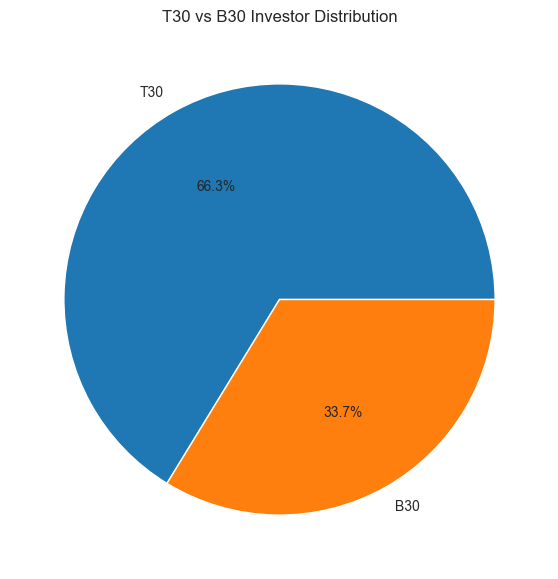

In [494]:
plt.figure(figsize=(7,7))

tx["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("T30 vs B30 Investor Distribution")

plt.show()

### Insight 6

T30 cities account for approximately two-thirds of all investor transactions, while B30 cities contribute nearly one-third. This indicates that mutual fund adoption is expanding beyond major metropolitan areas.

In [495]:
tx.groupby("state")["amount_inr"] \
  .sum() \
  .sort_values(ascending=False) \
  .head(10)

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64

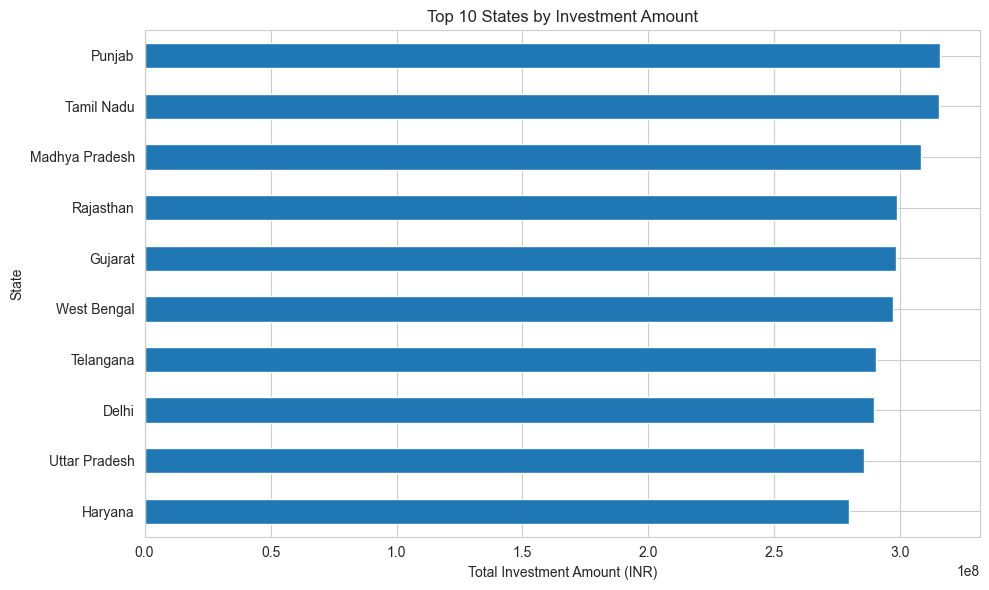

In [496]:
state_amt = (
    tx.groupby("state")["amount_inr"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

state_amt.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 States by Investment Amount")
plt.xlabel("Total Investment Amount (INR)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### Insight 7

Punjab recorded the highest total investment amount in the dataset, followed closely by Tamil Nadu and Madhya Pradesh. Investment activity is geographically diversified across multiple states rather than being concentrated in a single region.

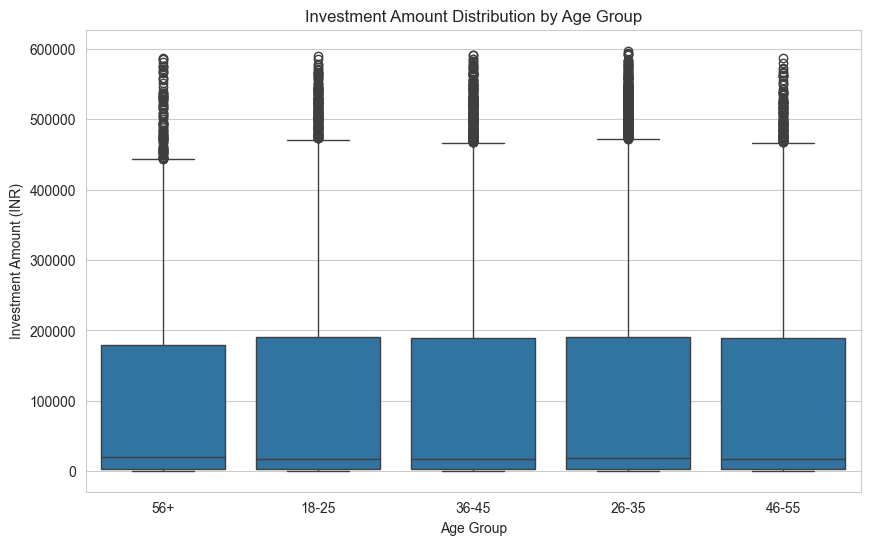

In [497]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=tx,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")

plt.show()

### Insight 8

Investment amounts vary significantly across all age groups, with noticeable outliers representing high-value investments. The 26–35 and 36–45 age groups show both high participation and a wide range of investment sizes, indicating strong engagement from working-age investors.

In [498]:
perf[["amfi_code", "scheme_name"]].head(10)

,amfi_code,scheme_name
0,119551,SBI Bluechip Fund - Regular Plan - Growth
1,119552,SBI Bluechip Fund - Direct Plan - Growth
2,119598,SBI Small Cap Fund - Regular Plan - Growth
3,119599,SBI Small Cap Fund - Direct Plan - Growth
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth
5,100016,HDFC Top 100 Fund - Regular Plan - Growth
6,125497,HDFC Top 100 Fund - Direct Plan - Growth
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth
9,100025,HDFC Short Term Debt Fund - Regular - Growth


In [499]:
selected_funds = [
    119551,
    119552,
    119598,
    119599,
    119120,
    100016,
    125497,
    100033,
    125498,
    100025
]

nav_10 = nav[nav["amfi_code"].isin(selected_funds)]

print(nav_10.shape)

(11500, 3)


In [500]:
pivot_nav = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

pivot_nav.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,42.1391,54.3856,58.4174,89.8738,96.4565,560.1443,117.5969
2022-01-04,515.0971,26.2234,105.9447,42.2508,54.3474,57.3480,88.5495,94.6512,560.7052,117.0077
2022-01-05,521.7239,26.2221,105.4800,42.4374,54.6869,57.0552,88.0925,94.5436,563.0884,116.4011
2022-01-06,515.7880,26.1728,104.9350,42.5901,55.4550,56.4224,88.5175,93.7944,561.0675,116.0861
2022-01-07,515.1639,26.2261,104.3318,42.4851,55.3692,57.2750,91.4235,89.6438,559.5420,114.6164


In [501]:
returns = pivot_nav.pct_change().dropna()

returns.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.002651,-0.000702,-0.018306,-0.014735,-0.018716,0.001001,-0.005010
2022-01-05,0.012865,-0.000050,-0.004386,0.004416,0.006247,-0.005106,-0.005161,-0.001137,0.004250,-0.005184
2022-01-06,-0.011377,-0.001880,-0.005167,0.003598,0.014045,-0.011091,0.004824,-0.007924,-0.003589,-0.002706
2022-01-07,-0.001210,0.002036,-0.005748,-0.002465,-0.001547,0.015111,0.032830,-0.044252,-0.002719,-0.012660
2022-01-10,-0.008639,0.006791,0.006277,-0.000353,-0.001548,0.009465,0.051113,0.033761,0.003057,-0.019536


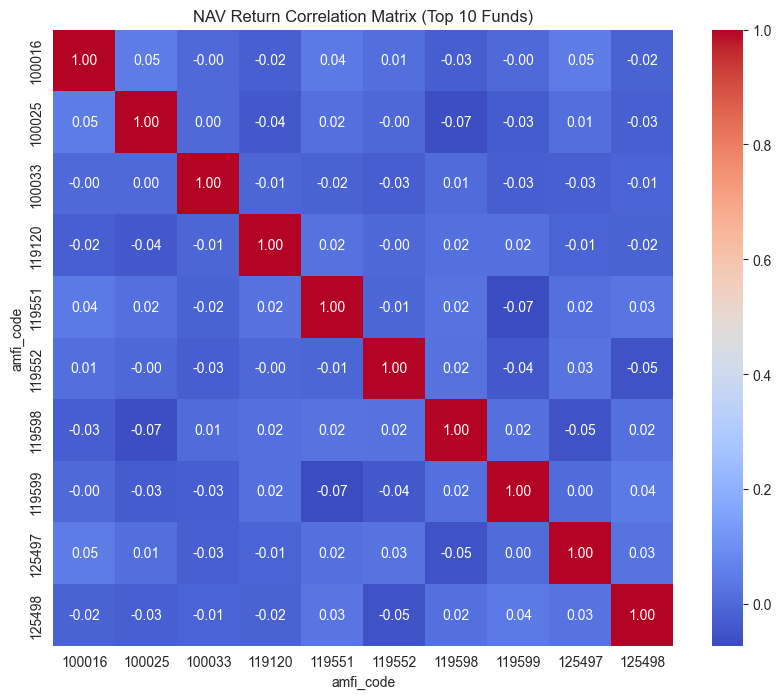

In [502]:
corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix (Top 10 Funds)")

plt.show()

### Insight 9

Most equity-oriented mutual funds exhibit positive correlations, indicating that they tend to move in the same direction during market cycles. Debt-oriented funds generally show lower correlation with equity funds, providing diversification benefits to investors.

In [503]:
holdings = pd.read_csv(DATA / "portfolio_holdings_clean.csv")

holdings.shape

(322, 8)

In [504]:
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [505]:
sector_weights = (
    holdings.groupby("sector")["weight_pct"]
            .sum()
            .sort_values(ascending=False)
)

sector_weights.head(10)

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
Name: weight_pct, dtype: float64

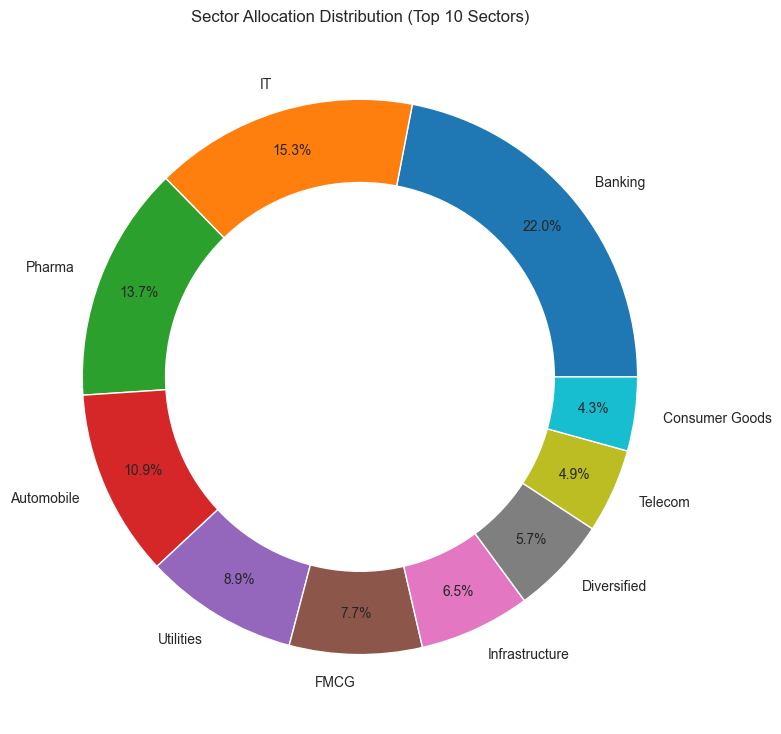

In [506]:
top_sectors = sector_weights.head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top_sectors,
    labels=top_sectors.index,
    autopct="%1.1f%%",
    pctdistance=0.85
)

centre_circle = plt.Circle((0,0),0.70,fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Distribution (Top 10 Sectors)")

plt.tight_layout()
plt.show()

### Insight 10

Banking is the largest sector allocation across mutual fund portfolios, followed by IT and Pharma. This indicates a strong preference for financially stable and growth-oriented sectors within diversified mutual fund holdings.

In [507]:
aum = pd.read_csv(DATA / "aum_by_fund_house_clean.csv")

print(aum.shape)

aum.head()

(90, 5)


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [508]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [509]:
aum["year"].unique()

array([2022, 2023, 2024, 2025], dtype=int32)

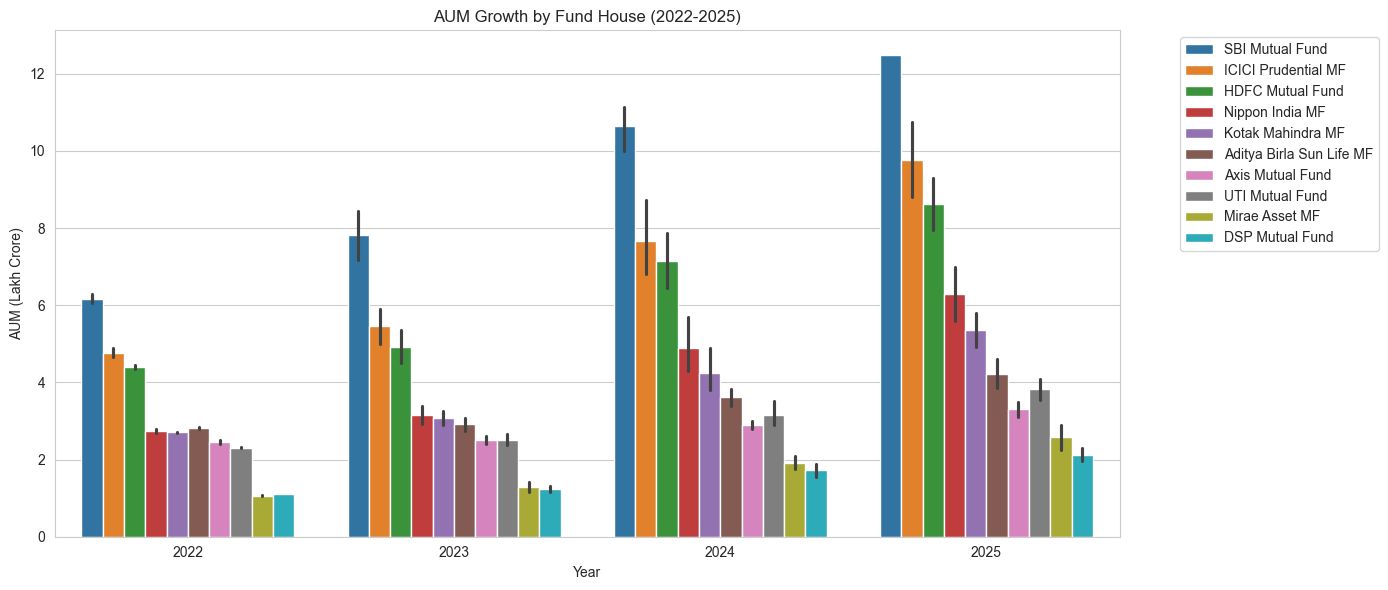

In [510]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Insight 11

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) across the analysis period, demonstrating strong investor trust and market leadership. Major fund houses such as ICICI Prudential MF and HDFC Mutual Fund also showed steady AUM growth.

In [511]:
sip = pd.read_csv(DATA / "monthly_sip_inflows_clean.csv")

print(sip.shape)

sip.head()

(48, 6)


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [512]:
sip["month"] = pd.to_datetime(sip["month"])

sip.dtypes

month                        datetime64[us]
sip_inflow_crore                      int64
active_sip_accounts_crore           float64
new_sip_accounts_lakh               float64
sip_aum_lakh_crore                  float64
yoy_growth_pct                      float64
dtype: object

In [513]:
sip.loc[sip["sip_inflow_crore"].idxmax()]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [514]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022-2025)"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="All-Time High: ₹31,002 Cr",
    showarrow=True
)

fig.show()

### Insight 12

Monthly SIP inflows showed a strong upward trend throughout the analysis period, reaching an all-time high of ₹31,002 crore in December 2025. This reflects increasing retail investor participation and growing confidence in systematic investment plans.

In [515]:
cat_inflow = pd.read_csv(DATA / "category_inflows_clean.csv")

print(cat_inflow.shape)

cat_inflow.head()

(144, 3)


,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [516]:
cat_inflow["month"] = pd.to_datetime(cat_inflow["month"])

heatmap_data = cat_inflow.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


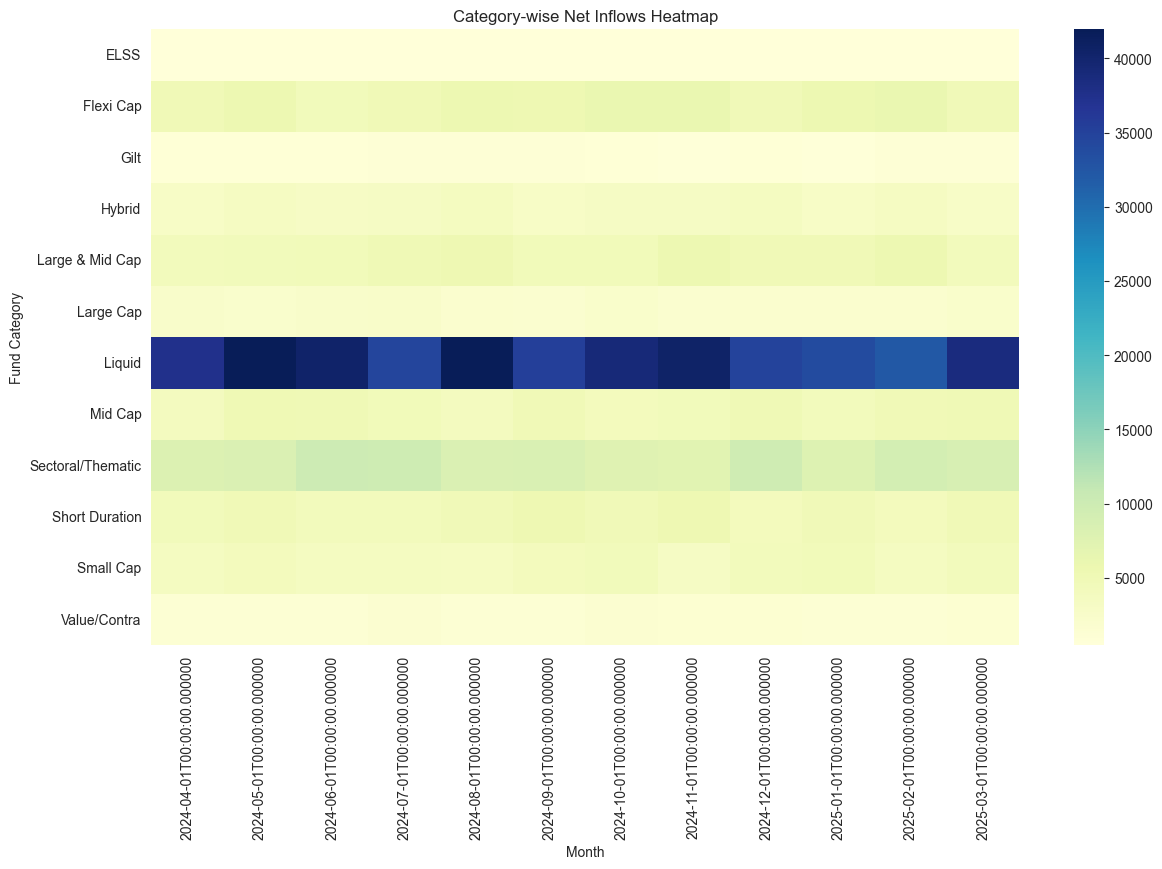

In [517]:
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()

### Insight 13

Category inflows vary significantly across time periods, with equity-oriented categories such as Large Cap, Mid Cap, Small Cap, and Flexi Cap consistently attracting strong investor interest. Market sentiment appears to influence category-level capital flows.

In [518]:
folio = pd.read_csv(DATA / "industry_folio_count_clean.csv")

print(folio.shape)

folio.head()

(21, 6)


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [519]:
folio["month"] = pd.to_datetime(folio["month"])

folio.dtypes

month                  datetime64[us]
total_folios_crore            float64
equity_folios_crore           float64
debt_folios_crore             float64
hybrid_folios_crore           float64
others_folios_crore           float64
dtype: object

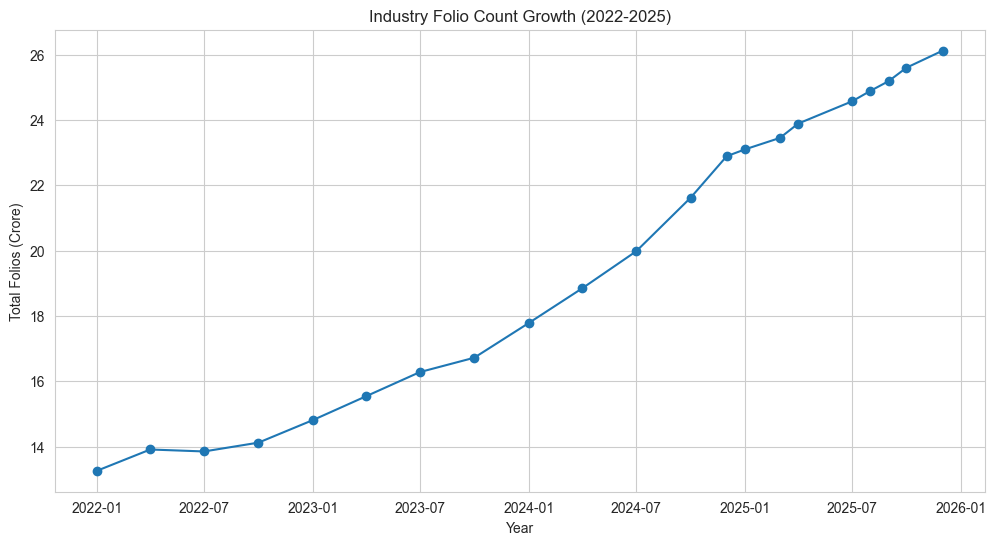

In [520]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Count Growth (2022-2025)")
plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.show()

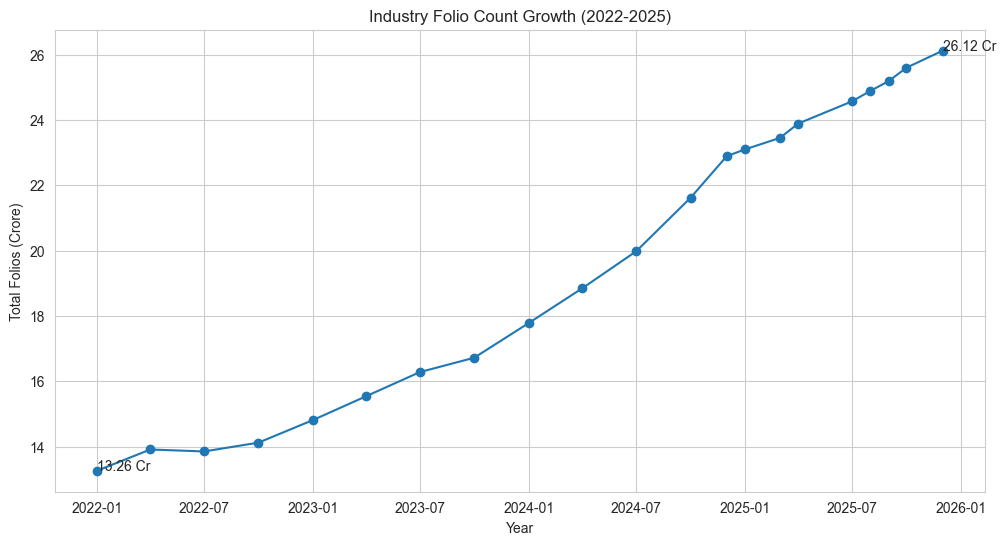

In [521]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.annotate(
    "13.26 Cr",
    xy=(folio["month"].iloc[0], folio["total_folios_crore"].iloc[0])
)

plt.annotate(
    "26.12 Cr",
    xy=(folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1])
)

plt.title("Industry Folio Count Growth (2022-2025)")
plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.show()

### Insight 14

Total mutual fund folios nearly doubled during the analysis period, increasing from 13.26 crore in early 2022 to approximately 26.12 crore by the end of 2025. This highlights rapid growth in retail investor participation across the mutual fund industry.

In [522]:
nav["date"].min(), nav["date"].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [523]:
daily_nav = (
    nav.groupby("date")["nav"]
       .mean()
       .reset_index()
)

fig = px.line(
    daily_nav,
    x="date",
    y="nav",
    title="Average Daily NAV Trend (2022-2026)"
)

# 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    fillcolor="green",
    opacity=0.15,
    line_width=0
)

# 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="2024 Correction",
    fillcolor="red",
    opacity=0.15,
    line_width=0
)

fig.show()

### Insight 15

Average mutual fund NAVs displayed a long-term upward trend throughout the analysis period. The highlighted 2023 period reflects strong market momentum, while the 2024 period represents a correction phase, demonstrating the cyclical nature of financial markets.

In [525]:
all_funds = nav["amfi_code"].nunique()

print(all_funds)

40


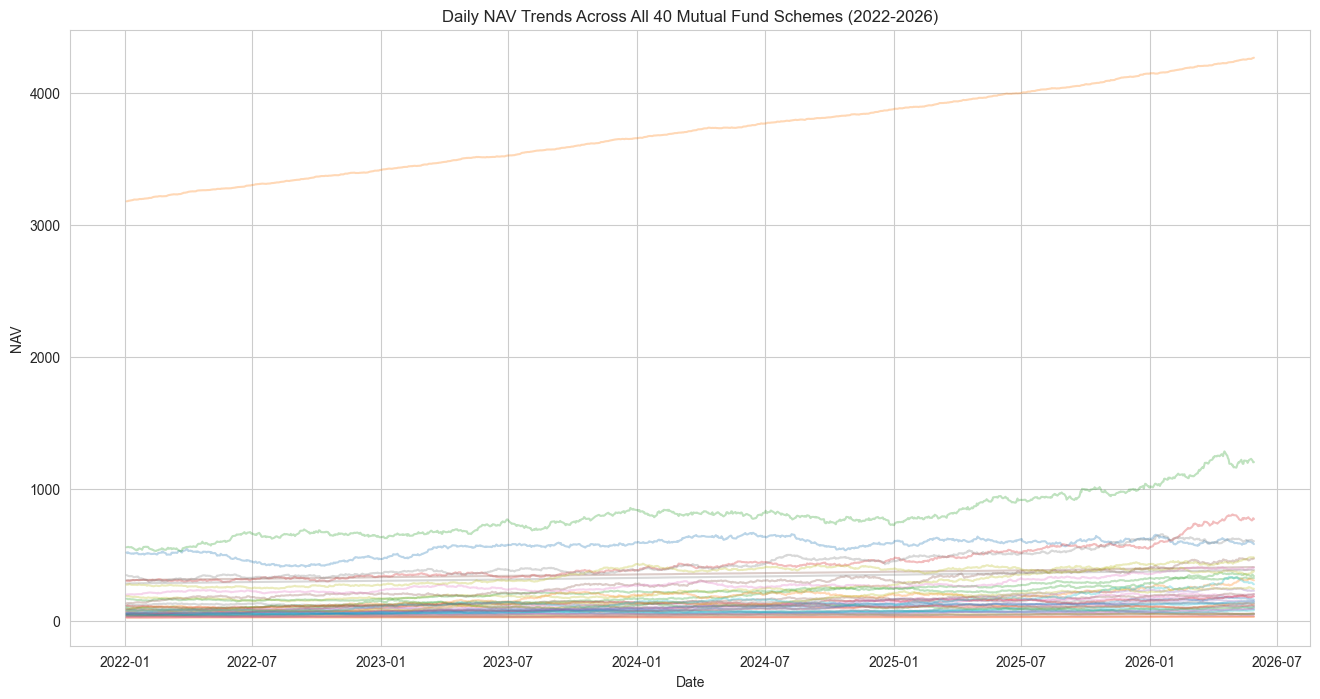

In [526]:
plt.figure(figsize=(16,8))

for code in nav["amfi_code"].unique():
    temp = nav[nav["amfi_code"] == code]

    plt.plot(
        temp["date"],
        temp["nav"],
        alpha=0.3
    )

plt.title("Daily NAV Trends Across All 40 Mutual Fund Schemes (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.show()

### Insight 16

Daily NAV trends across all 40 mutual fund schemes indicate varying growth trajectories and volatility levels. While short-term fluctuations differ across schemes, the majority of funds demonstrate a positive long-term trend, reflecting overall growth in the mutual fund industry.